In [17]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from typing import Pattern

from utils import *

# Parser
COACH_DIR = Path("/Users/hyeon/SeSAC_Project/Coach")    # Coach의 절대경로 입력
RUN_FOLDER = "test14"
RUN_DIR = COACH_DIR / "run" / RUN_FOLDER

# 루트 디렉토리 바로 아래의 pose_predictions.json 지정
OUTPUTS_DIR = RUN_DIR / "outputs"

user = RUN_DIR / "user_info.json"
with user.open(mode="r", encoding='utf-8') as file:
    user_data = json.load(file)

hpe = OUTPUTS_DIR / "pose_predictions.json"
with hpe.open(mode="r", encoding='utf-8') as file:
    pose_data = json.load(file)

details = OUTPUTS_DIR / "details.json"
with details.open(mode="r", encoding='utf-8') as file:
    detail_data = json.load(file)

ps = PoseSequence(pose_data, detail_data, user_data)


In [18]:
ps.cal_stride()
ps.pixel2m()

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.00183993589265602 / pixel 입니다.


np.float64(978.2949542886677)

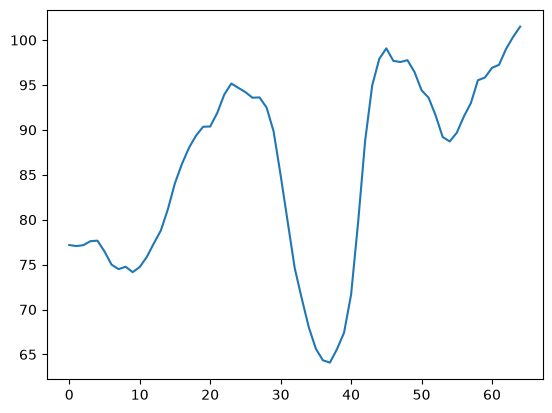

In [20]:
plt.plot(ps.joint_angle("right_elbow", smooth=True))

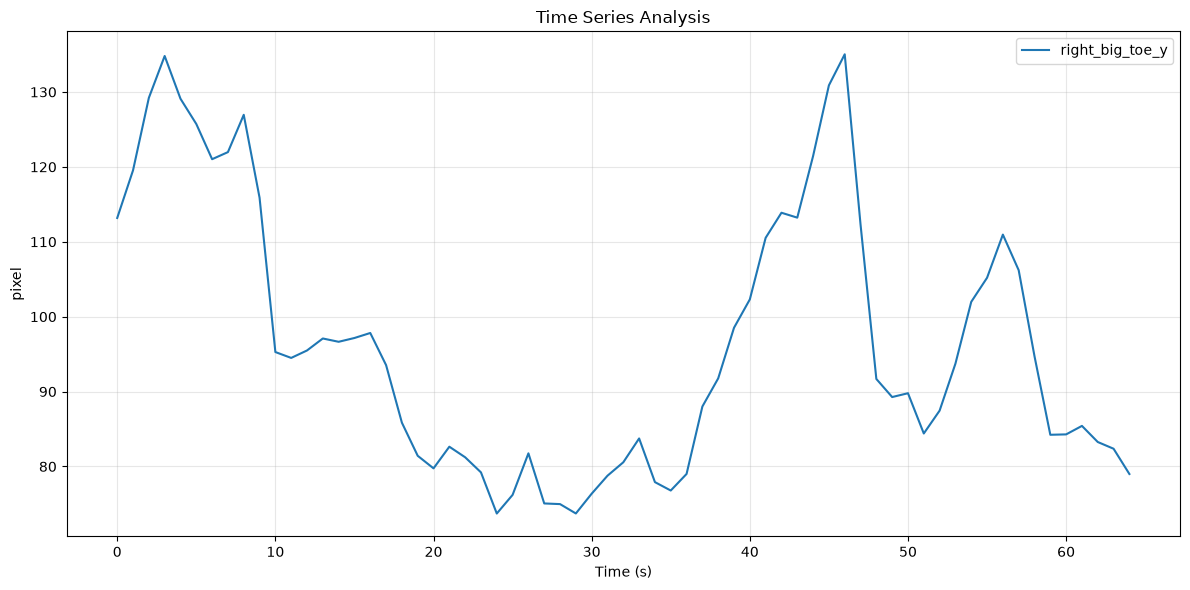

In [26]:
visualize_frame(ps.df['right_big_toe_y'])

In [12]:
ps.strides

,frame,value,class
1,7,86.384202,1
2,18,9.953136,0
3,28,33.111829,1
4,32,24.101460,0
1,46,85.720479,1
2,57,8.816819,0


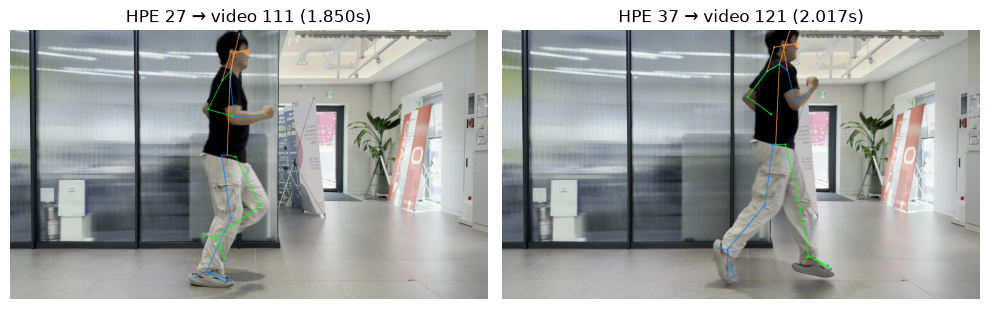

[array([[[152, 158, 162],
         [151, 157, 161],
         [151, 157, 161],
         ...,
         [129, 129, 118],
         [129, 129, 118],
         [129, 129, 118]],
 
        [[150, 155, 160],
         [148, 154, 159],
         [148, 154, 159],
         ...,
         [130, 130, 119],
         [130, 130, 119],
         [130, 130, 119]],
 
        [[147, 153, 158],
         [146, 152, 157],
         [146, 152, 157],
         ...,
         [130, 130, 119],
         [130, 130, 119],
         [130, 130, 119]],
 
        ...,
 
        [[171, 172, 169],
         [169, 171, 168],
         [168, 169, 167],
         ...,
         [138, 139, 134],
         [137, 138, 133],
         [137, 138, 133]],
 
        [[173, 174, 172],
         [172, 173, 171],
         [169, 171, 168],
         ...,
         [137, 138, 133],
         [137, 138, 133],
         [137, 138, 133]],
 
        [[172, 173, 171],
         [172, 173, 171],
         [171, 172, 169],
         ...,
         [137, 138, 133],
  

In [4]:
show_video_frames(
    "/Users/hyeon/SeSAC_Project/Coach/run/test14/outputs/output.mp4",
    [27, 37],
    hpe_start_frame=84,
    columns=2
)

In [3]:
ps.gct()

[] 55 34


AssertionError: None

In [ ]:
elbow = ps.joint_angle('left_elbow', smooth=True, negative=False)

In [10]:
elbow

array([ 46.00639761,  36.09196752,  30.43155056,  29.53707948,
        31.88153882,  36.13049023,  40.64906621,  44.94981051,
        48.77455153,  52.91207569,  55.81493047,  59.13223631,
        62.15242508,  65.11190661,  67.25473454,  69.23977491,
        71.37374847,  74.14378585,  75.96153863,  77.59239142,
        79.91250136,  83.56751288,  88.29321289,  93.77019472,
       100.08735071, 106.23524142, 112.84439928, 117.77581855,
       121.82933544, 125.04560647, 128.24715163, 128.87053034,
       127.64260176, 123.44019767, 118.41974634, 111.84378644,
       105.92611086,  97.25871697,  88.59121736,  79.49995552,
        71.92910942,  62.89048326,  53.22482513,  43.69217157,
        37.41013193,  33.32127134,  29.88270853,  26.51903811,
        27.62619497,  30.7745516 ,  35.20248372,  39.35702913,
        44.57919798,  47.56234203,  50.35342918,  53.99967403,
        58.39151016,  62.86841064,  66.93910978,  70.67690661,
        73.67732977,  76.18067832,  77.83252568,  79.18

In [12]:
elbow.max()

np.float64(128.8705303360683)

In [7]:
len(elbow)

80

In [9]:
len(ps.df)

80

In [3]:
distance = ps.details["video"]['fps'] // 6